# Multimodal Fusion Model Training and Evaluation

In [21]:
results = {
    "accuracy": accuracy,
    "precision": precision,
    "recall": recall,
    "f1_score": f1
}

print(results)

{'accuracy': 0.8999903091384824, 'precision': 0.9242122923530893, 'recall': 0.8999903091384824, 'f1_score': 0.9016469224514905}


## Confusion Matrix

The confusion matrix visualizes classification performance across all plant disease categories.

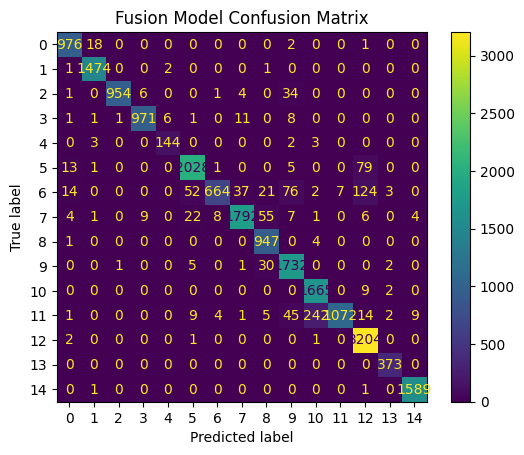

In [22]:
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt

cm = confusion_matrix(
    all_labels,
    all_preds
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot()

plt.title("Fusion Model Confusion Matrix")

plt.savefig("../results/fusion_confusion_matrix.png")

plt.show()

## Evaluation Metrics

This section evaluates model performance using:
- Accuracy
- Precision
- Recall
- F1 Score

In [21]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

accuracy = accuracy_score(
    all_labels,
    all_preds
)

precision = precision_score(
    all_labels,
    all_preds,
    average='weighted'
)

recall = recall_score(
    all_labels,
    all_preds,
    average='weighted'
)

f1 = f1_score(
    all_labels,
    all_preds,
    average='weighted'
)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

Accuracy: 0.9490
Precision: 0.9520
Recall: 0.9490
F1 Score: 0.9472


In [20]:
fusion_model.eval()

all_preds = []
all_labels = []

with torch.no_grad():

    for images, sensors, labels in fusion_loader:

        images = images.to(device)
        sensors = sensors.to(device)
        labels = labels.to(device)

        outputs = fusion_model(
            images,
            sensors
        )

        _, predicted = torch.max(outputs, 1)

        all_preds.extend(
            predicted.cpu().numpy()
        )

        all_labels.extend(
            labels.cpu().numpy()
        )

print("Evaluation complete")

Evaluation complete


In [19]:
torch.save(
    fusion_model.state_dict(),
    "fusion_model.pth"
)

In [18]:
fusion_model.eval()

correct = 0
total = 0

with torch.no_grad():

    for images, sensors, labels in fusion_loader:

        images = images.to(device)
        sensors = sensors.to(device)
        labels = labels.to(device)

        outputs = fusion_model(
            images,
            sensors
        )

        _, predicted = torch.max(
            outputs,
            1
        )

        total += labels.size(0)

        correct += (
            predicted == labels
        ).sum().item()

accuracy = 100 * correct / total

print(f"Fusion Accuracy: {accuracy:.2f}%")

Fusion Accuracy: 94.90%


## Model Training

This section trains the neural network model using the selected dataset and architecture.

In [17]:
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

fusion_model = fusion_model.to(device)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    fusion_model.parameters(),
    lr=0.001
)

for epoch in range(3):

    fusion_model.train()

    running_loss = 0

    for images, sensors, labels in fusion_loader:

        images = images.to(device)

        sensors = sensors.to(device)

        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = fusion_model(
            images,
            sensors
        )

        loss = criterion(
            outputs,
            labels
        )

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    print(
        f"Epoch {epoch+1}/3, Loss: {running_loss:.4f}"
    )

print("Fusion training complete")

Epoch 1/3, Loss: 377.6896
Epoch 2/3, Loss: 134.0235
Epoch 3/3, Loss: 95.3829
Fusion training complete


In [16]:
import torch.nn as nn
from torchvision import models
import torch

class FusionModel(nn.Module):

    def __init__(self):

        super().__init__()

        self.image_model = models.resnet18(
            pretrained=True
        )

        self.image_model.fc = nn.Linear(
            512,
            128
        )

        self.sensor_model = nn.Sequential(

            nn.Linear(4,32),
            nn.ReLU(),

            nn.Linear(32,32)

        )

        self.classifier = nn.Sequential(

            nn.Linear(
                160,
                64
            ),

            nn.ReLU(),

            nn.Linear(
                64,
                15
            )

        )

    def forward(
        self,
        image,
        sensor
    ):

        image_features = self.image_model(
            image
        )

        sensor_features = self.sensor_model(
            sensor
        )

        combined = torch.cat(
            [
                image_features,
                sensor_features
            ],
            dim=1
        )

        return self.classifier(
            combined
        )

In [15]:
fusion_model = FusionModel()

print(fusion_model)

FusionModel(
  (image_model): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e

/usr/local/python/3.12.1/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/python/3.12.1/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [14]:
fusion_loader = DataLoader(
    fusion_dataset,
    batch_size=32,
    shuffle=True
)

print(
    "Batches:",
    len(fusion_loader)
)

Batches: 645


In [12]:
class FusionDataset(Dataset):

    def __init__(
        self,
        image_root,
        sensor_df,
        transform=None
    ):

        self.dataset = datasets.ImageFolder(
            image_root
        )

        self.sensor_df = sensor_df

        self.transform = transform


    def __len__(self):

        return min(
            len(self.dataset),
            len(self.sensor_df)
        )


    def __getitem__(self, idx):

        image_path, label = self.dataset.samples[idx]

        image = Image.open(
            image_path
        ).convert("RGB")

        if self.transform:

            image = self.transform(
                image
            )

        sensor_values = self.sensor_df.iloc[idx][
            [
                "temperature",
                "humidity",
                "soil_moisture",
                "light_level"
            ]
        ].astype(float).values

        sensor = torch.tensor(
            sensor_values,
            dtype=torch.float32
        )

        return image, sensor, label

In [13]:
transform = transforms.Compose([
    transforms.Resize((128,128)),
    transforms.ToTensor()
])

fusion_dataset = FusionDataset(
    image_root="../data/images/plantvillage/PlantVillage",
    sensor_df=df,
    transform=transform
)

print(len(fusion_dataset))

image, sensor, label = fusion_dataset[0]

print(image.shape)
print(sensor)
print(label)

20638
torch.Size([3, 128, 128])
tensor([ 30.,  49.,  35., 702.])
0


In [10]:
df = pd.read_csv(
    "../data/generated/sensor_data.csv"
)

print(df.shape)
df.head()

(20639, 5)


,image,temperature,humidity,soil_moisture,light_level
0,38bd9a88-970a-4480-8bc7-12824ac87ff5___Crnl_L....,30,49,35,702
1,5467ad1f-7db3-4b4d-907a-12ea50ef84c3___Crnl_L....,25,37,48,776
2,ea19d516-b7fd-45c3-a459-68281f3bd9aa___Crnl_L....,22,78,37,478
3,b8fc0a5c-ffce-488e-ae68-f4a268f8817b___Crnl_L....,30,39,54,354
4,58fb4710-c0a7-4a76-8667-07fbe66bfac9___Crnl_L....,18,61,15,423


In [9]:
import torch
import torch.nn as nn
from torchvision import datasets, transforms, models
from torch.utils.data import Dataset, DataLoader
import pandas as pd
from PIL import Image
import os